<a href="https://colab.research.google.com/github/nithishkannan765-stack/Data-Analystics-Python-project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

employees = {
    "Emp_ID": [1001, 1002, 1003, 1004, 1005, 1006],
    "Name": ["Nithish", "Siva", "Karthi", "Divya", "Arun", "Meena"],
    "Department": ["IT", "HR", "IT", "Sales", "Finance", "HR"],
    "Salary": [10000, 15000, 18000, 20000, 25000, 12000],
    "Experience": [3, 4, 3, 2, 6, 1],
    "JobSatisfaction": [3, 4, 2, 3, 5, 2],
    "WorkLifeBalance": [4, 3, 2, 3, 4, 2],
    "Attrition": ["Yes", "No", "Yes", "Yes", "No", "Yes"]
}



In [22]:
df = pd.DataFrame(employees)
print("Original Dataset:")
print(df)


Original Dataset:
   Emp_ID     Name Department  Salary  Experience  JobSatisfaction  \
0    1001  Nithish         IT   10000           3                3   
1    1002     Siva         HR   15000           4                4   
2    1003   Karthi         IT   18000           3                2   
3    1004    Divya      Sales   20000           2                3   
4    1005     Arun    Finance   25000           6                5   
5    1006    Meena         HR   12000           1                2   

   WorkLifeBalance Attrition  
0                4       Yes  
1                3        No  
2                2       Yes  
3                3       Yes  
4                4        No  
5                2       Yes  


In [23]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df['Experience'] = df['Experience'].fillna(df['Experience'].mean())
df['JobSatisfaction'] = df['JobSatisfaction'].fillna(df['JobSatisfaction'].mode()[0])
df['WorkLifeBalance'] = df['WorkLifeBalance'].fillna(df['WorkLifeBalance'].mode()[0])



In [36]:
df = df.drop_duplicates()


In [35]:
df['Department'] = df['Department'].str.title()
df['Name'] = df['Name'].str.title()


In [27]:
print("\nCleaned Dataset:")
print(df)


Cleaned Dataset:
   Emp_ID     Name Department  Salary  Experience  JobSatisfaction  \
0    1001  Nithish         It   10000           3                3   
1    1002     Siva         Hr   15000           4                4   
2    1003   Karthi         It   18000           3                2   
3    1004    Divya      Sales   20000           2                3   
4    1005     Arun    Finance   25000           6                5   
5    1006    Meena         Hr   12000           1                2   

   WorkLifeBalance Attrition  
0                4       Yes  
1                3        No  
2                2       Yes  
3                3       Yes  
4                4        No  
5                2       Yes  



Attrition Rate (%):
Attrition
Yes    66.666667
No     33.333333
Name: proportion, dtype: float64


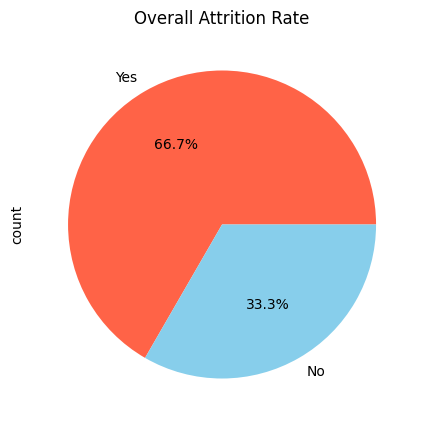

In [29]:
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("\nAttrition Rate (%):")
print(attrition_rate)

plt.figure(figsize=(5,5))
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', colors=['tomato','skyblue'])
plt.title("Overall Attrition Rate")
plt.show()


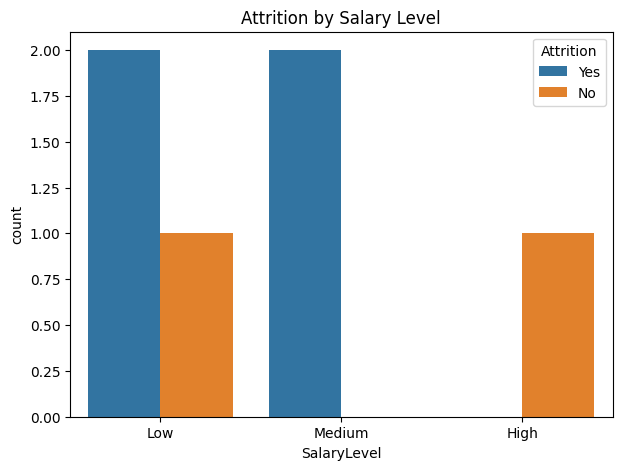

In [30]:
df['SalaryLevel'] = pd.cut(df['Salary'], bins=[0,15000,22000,30000],
                           labels=['Low','Medium','High'])

plt.figure(figsize=(7,5))
sns.countplot(x='SalaryLevel', hue='Attrition', data=df)
plt.title("Attrition by Salary Level")
plt.show()


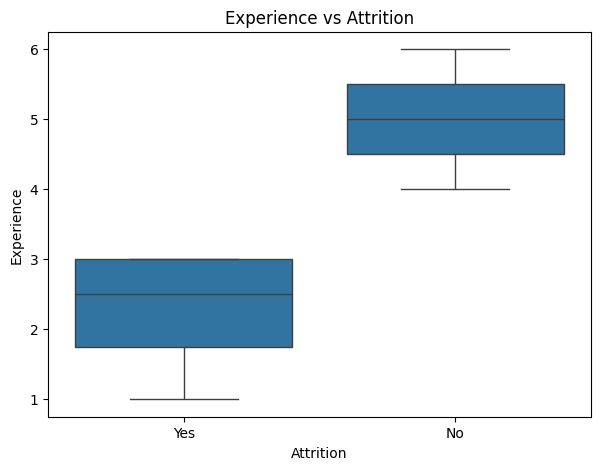

In [31]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Attrition', y='Experience', data=df)
plt.title("Experience vs Attrition")
plt.show()


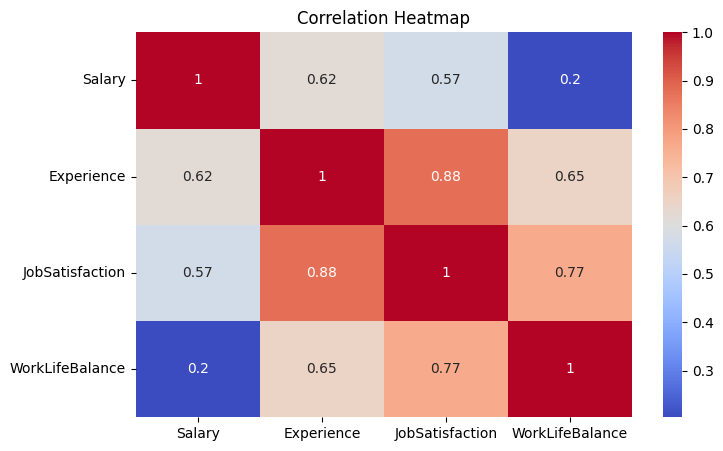

In [32]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Salary','Experience','JobSatisfaction','WorkLifeBalance']]
            .corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [33]:
print("\n--- KEY INSIGHTS ---")

if df[df['Attrition']=="Yes"]['Salary'].mean() < df[df['Attrition']=="No"]['Salary'].mean():
    print("Low salary employees tend to leave more.")

if df[df['Attrition']=="Yes"]['Experience'].mean() < df[df['Attrition']=="No"]['Experience'].mean():
    print("Employees with less experience leave more.")

if df[df['Attrition']=="Yes"]['JobSatisfaction'].mean() < df[df['Attrition']=="No"]['JobSatisfaction'].mean():
    print("Low job satisfaction increases attrition.")

high_attrition_dept = df[df['Attrition']=="Yes"]['Department'].value_counts().idxmax()
print(f"Highest attrition department: {high_attrition_dept}")



--- KEY INSIGHTS ---
Low salary employees tend to leave more.
Employees with less experience leave more.
Low job satisfaction increases attrition.
Highest attrition department: It
